In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

[28.56557215]
-2.249762043276304


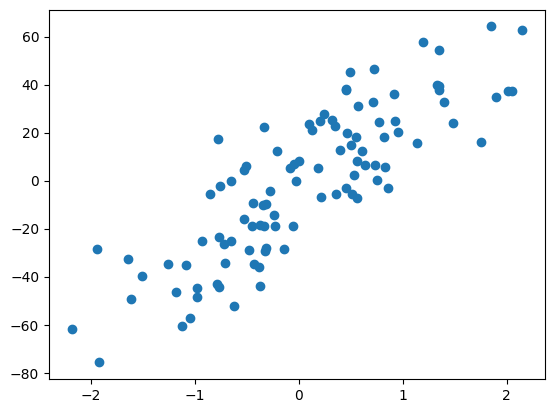

In [2]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)

c:\MLDL\100-days-of-machine-learning\.venv\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\MLDL\100-days-of-machine-learning\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\MLDL\100-days-of-machine-learning\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.183e+04, tolerance: 8.344e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeC

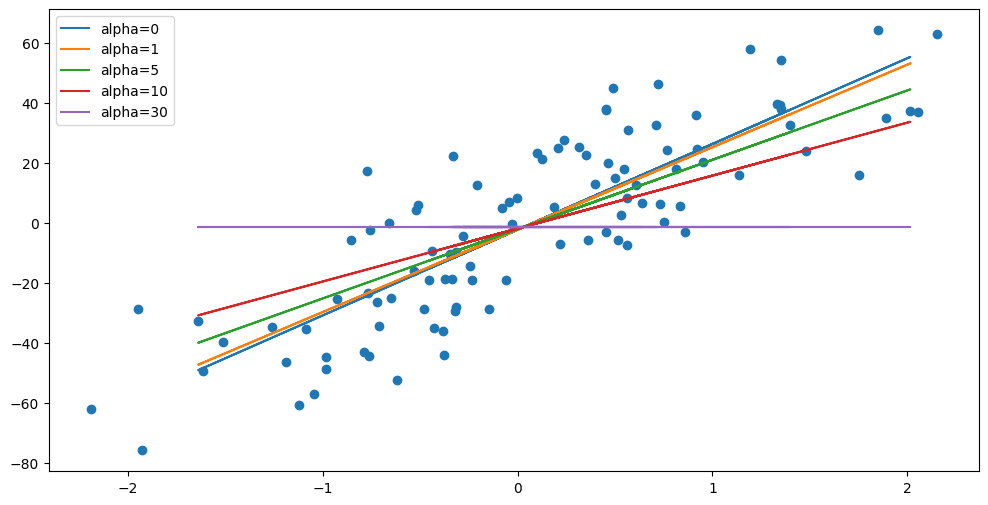

In [ ]:
alphas = [0,1,5,10,30]
plt.figure(figsize=(12,6))#plt.figure(figsize=(12,6)) means that the figure will be 12 inches wide and 6 inches tall. This allows for a larger and clearer visualization of the plot, making it easier to see the differences between the lines corresponding to different alpha values in the Lasso regression.
plt.scatter(X,y)
for i in alphas:
    L = Lasso(alpha=i)
    L.fit(X_train,y_train)
    plt.plot(X_test,L.predict(X_test),label='alpha={}'.format(i))#plt.plot(X_test,L.predict(X_test),label='alpha={}'.format(i)) means that for each alpha value in the alphas list, a Lasso regression model is fitted to the training data (X_train, y_train). Then, the predicted values for the test set (X_test) are plotted against the actual values (y) using plt.plot(). The label for each line in the plot is set to indicate the corresponding alpha value, which helps in distinguishing between the different lines representing different levels of regularization in the Lasso regression.plt.plot have first argument as X_test which is the input data for the test set, and the second argument is L.predict(X_test) which gives the predicted values from the Lasso regression model for the test set. The label parameter is used to create a legend that indicates which line corresponds to which alpha value.
    # label='alpha={}'.format(i)) here fomate i is used to insert the value of i (the current alpha value) into the string 'alpha={}'. This allows the label for each line in the plot to dynamically reflect the corresponding alpha value, making it easier to identify which line corresponds to which level of regularization in the Lasso regression.
plt.legend()#legent means that it adds a legend to the plot, which is a box that identifies the different lines or markers in the plot based on their labels. In this case, it will show the labels for each line corresponding to different alpha values in the Lasso regression, making it easier to understand which line represents which alpha value.
plt.show()
    

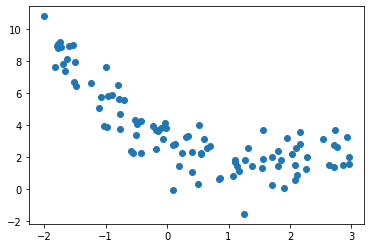

In [ ]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2 # x1 is generated as a random array of shape (m, 1) where m is the number of samples (100 in this case). The values in x1 are generated by taking random numbers from a uniform distribution between 0 and 1 (using np.random.rand(m, 1)), scaling them by 5 (to get a range of 0 to 5), and then shifting them by -2 (to get a final range of -2 to 3). This creates a set of random values for x1 that can be used as input features for regression or other machine learning tasks.
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

C:\Users\91842\anaconda3\lib\site-packages\sklearn\pipeline.py:346: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  self._final_estimator.fit(Xt, y, **fit_params_last_step)
C:\Users\91842\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\91842\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 49.81683621641182, tolerance: 0.06499967674566547
  model = cd_fast.enet_coordinate_descent(
C:\Users\91842\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 71.0249

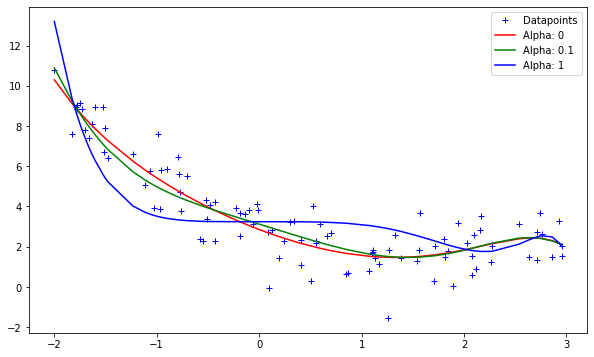

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

def get_preds_lasso(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('lasso', Lasso(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 0.1, 1]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):    
    preds = get_preds_lasso(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()